# Breast Cancer Dataset (SVM)



---


O Breast Cancer Wisconsin dataset é um conjunto de dados amplamente utilizado para tarefas de classificação binária, com o objetivo de prever se um tumor de mama é benigno ou maligno. Ele contém 569 amostras, cada uma descrita por 30 características numéricas extraídas de imagens de células tumorais, como raio, textura e suavidade. As classes são representadas como "maligno" e "benigno". **Vamos utilizar um modelo de SVM usando um kernel rbf para fazer classificação.**



---



## Imports

In [1]:
# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Manipulação de dados
import numpy as np
import pandas as pd

# Datasets
from sklearn.datasets import load_breast_cancer

# Modelos
from sklearn.svm import SVC

# Pré-processamento e divisão
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Avaliação
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
pip freeze > requirements.txt

## Carregando dataset e divindo conjuntos de treino e teste

In [ ]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

In [ ]:
# Normalizando os dados

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Divindo o dataset em conjuntos de treino e teste

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=12, stratify = y)

## Instância e avaliação do modelo


In [ ]:
# Instanciar e treinar o modelo

model = SVC(kernel='rbf') # rbf kernel
model.fit(X_train, y_train)

# Predição

y_pred = model.predict(X_test)

In [ ]:
# Avaliando o modelo

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



## Visualização

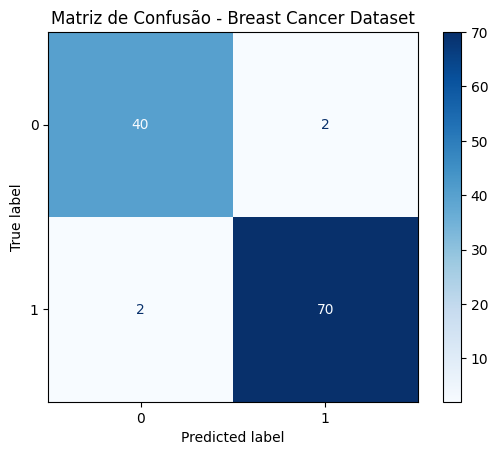

In [ ]:
# Matriz de confusão

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap ='Blues')
plt.title('Matriz de Confusão - Breast Cancer Dataset')
plt.show()

### PCA

PCA (Análise de Componentes Principais) é uma técnica de redução de dimensionalidade que ajuda a diminuir o número de características de um conjunto de dados, preservando a maior parte das informações importantes. Ela remove redundâncias nos dados, melhora a eficiência computacional e facilita a visualização, especialmente quando lidamos com conjuntos de dados de muitas dimensões.

Utilizaremos essa técnica para reduzir o nosso conjunto de dados para somente duas features. Isso vai permitir visualizarmos a fronteira de decisão do modelo em duas dimensões!

In [ ]:
# PCA para reduzir dimensionalidade

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Avaliando o PCA

print(pca.explained_variance_ratio_) # Variância explicada
print(pca.explained_variance_ratio_.cumsum()) # Variância explicada acumulada

[0.44272026 0.18971182]
[0.44272026 0.63243208]


In [ ]:
# Divindo o dataset em conjuntos de treino e teste com PCA

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=12, stratify = y)

In [ ]:
# Instanciando modelo usando os dados com a dimensionalidade reduzida

model_pca = SVC(kernel='rbf') # rbf kernel
model_pca.fit(X_train_pca, y_train_pca)

SVC()

In [ ]:
# Calculando o meshgrid

h = 0.05  # Tamanho do passo: distância entre pontos vizinhos na grade

x_min, x_max = X_pca[:, 0].min() - h, X_pca[:, 0].max() + h
y_min, y_max = X_pca[:, 1].min() - h, X_pca[:, 1].max() + h

xx = np.linspace(x_min, x_max, 500)
yy = np.linspace(y_min, y_max, 500)

xx, yy = np.meshgrid(xx, yy)

In [ ]:
# Calculando a fronteira de decisão do modelo

Z = model_pca.decision_function(points_pca)
Z_linear = Z.reshape(xx.shape)

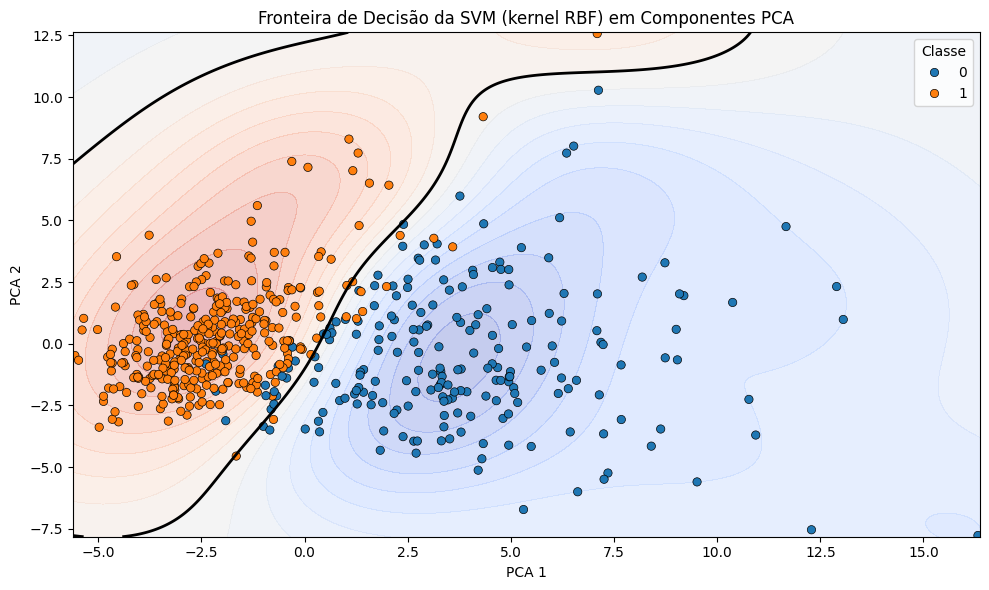

In [ ]:
# Gráfico da fronteira de decisão do modelo usando PCA

plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z_linear, levels=20, cmap='coolwarm', alpha=0.3) # Contornos coloridos
plt.contour(xx, yy, Z_linear, levels=[0], colors='k', linewidths=2) # Fronteira de decisão (levels = 0)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, edgecolor='k')

plt.title('Fronteira de Decisão da SVM (kernel RBF) em Componentes PCA', fontsize=12)
plt.xlabel('PCA 1', fontsize=10)
plt.ylabel('PCA 2', fontsize=10)

plt.legend(title='Classe')
plt.tight_layout()
plt.show()